# Lesson 07: Linear Regression
## Walkthrough: Predicting Weather & Cars

**AI/ML Course | Medina County Career Center**

In this walkthrough, we'll:
1. Explore correlations in real weather data (Sub-Lesson 07a)
2. Build a regression model to predict temperature (Sub-Lesson 07b)
3. Understand what the model learned

Pay close attention to the "cheating" explanation — it shows why realistic predictions are harder than they look.

## Setup: Imports and Helper Functions

Run this cell first to load all the libraries we need.

In [7]:
import pandas as pd                          # pandas = data tables (like Excel in Python)
import numpy as np                           # numpy = math operations on arrays
import matplotlib.pyplot as plt              # matplotlib = creates charts and graphs
import seaborn as sns                        # seaborn = makes prettier statistical charts
from sklearn.model_selection import train_test_split  # splits data into train/test
from sklearn.linear_model import LinearRegression     # linear regression algorithm
from sklearn.metrics import r2_score, mean_absolute_error  # accuracy metrics

# Set the random seed for reproducibility
np.random.seed(42)

## Sub-Lesson 07a — Correlation & Pearson r

### Step 1: Load the Weather Data

We'll use real data from Medina, Ohio throughout 2024. The file has 5 weather variables for each day.

In [8]:
# Load the weather data
# Relative path from ai06_Regression/ to ai06/
weatherData = pd.read_csv('medina_weather_2024.csv')

print(f"Loaded {len(weatherData)} days of weather data")
print("\nFirst 5 rows:")
print(weatherData.head())
print("\nData types:")
print(weatherData.dtypes)
print("\nBasic statistics:")
print(weatherData.describe().round(1))

Loaded 366 days of weather data

First 5 rows:
         date  temp_max  temp_min  precipitation  wind_speed  humidity
0  2024-01-01      36.5      23.2           0.00         7.4      38.3
1  2024-01-02      31.5       7.1           0.00         8.7      64.5
2  2024-01-03      37.9      27.7           0.00         7.9      62.5
3  2024-01-04      45.0      20.5           0.00         9.7      71.6
4  2024-01-05      31.1      20.5           0.21         6.0      82.9

Data types:
date              object
temp_max         float64
temp_min         float64
precipitation    float64
wind_speed       float64
humidity         float64
dtype: object

Basic statistics:
       temp_max  temp_min  precipitation  wind_speed  humidity
count     366.0     366.0          366.0       366.0     366.0
mean       57.0      39.5            0.1        12.1      68.7
std        19.6      20.6            0.3         4.2      13.3
min        19.0      -2.5            0.0         5.1      34.6
25%        40.2 

### Step 2: Check for Missing Values

Real data often has gaps (sensors down, transmission errors). We need to clean it before building a model.

In [9]:
# Check for missing values in each column
missingCounts = weatherData.isnull().sum()
print("Missing values per column:")
print(missingCounts)
print(f"\nRows before cleaning: {len(weatherData)}")

# Remove any row that has a missing value in any column
# .dropna() = "drop rows with any NaN (null) value"
weatherData = weatherData.dropna()

print(f"Rows after cleaning: {len(weatherData)}")

Missing values per column:
date             0
temp_max         0
temp_min         0
precipitation    0
wind_speed       0
humidity         0
dtype: int64

Rows before cleaning: 366
Rows after cleaning: 366


### Step 3: Calculate Correlations (Pearson r)

**Pearson r** measures how strongly two variables move together:
- **+1.0** = perfect positive (both increase together)
- **0.0** = no relationship
- **-1.0** = perfect negative (one increases, other decreases)

Let's calculate r for every pair of weather variables.

In [10]:
# Calculate Pearson r between all pairs of numeric columns
correlationMatrix = weatherData[['temp_max', 'temp_min', 'humidity', 'wind_speed', 'precipitation']].corr()

# Display as text
print("Pearson r Between All Weather Variables:\n")
print(correlationMatrix.round(3))
print("\nKey insights:")
print(f"  temp_max & temp_min: r = {correlationMatrix.loc['temp_max', 'temp_min']:.3f}  (almost perfect!)")
print(f"  temp_max & humidity: r = {correlationMatrix.loc['temp_max', 'humidity']:.3f}  (weak negative)")
print(f"  temp_max & wind_speed: r = {correlationMatrix.loc['temp_max', 'wind_speed']:.3f}  (weak negative)")

Pearson r Between All Weather Variables:

               temp_max  temp_min  humidity  wind_speed  precipitation
temp_max          1.000     0.978     0.069       0.533          0.049
temp_min          0.978     1.000     0.071       0.530          0.046
humidity          0.069     0.071     1.000      -0.129         -0.052
wind_speed        0.533     0.530    -0.129       1.000          0.002
precipitation     0.049     0.046    -0.052       0.002          1.000

Key insights:
  temp_max & temp_min: r = 0.978  (almost perfect!)
  temp_max & humidity: r = 0.069  (weak negative)
  temp_max & wind_speed: r = 0.533  (weak negative)


### Step 4: Visualize Correlations as a Heatmap

A heatmap makes it easy to spot strong relationships at a glance. Red = positive correlation, blue = negative.

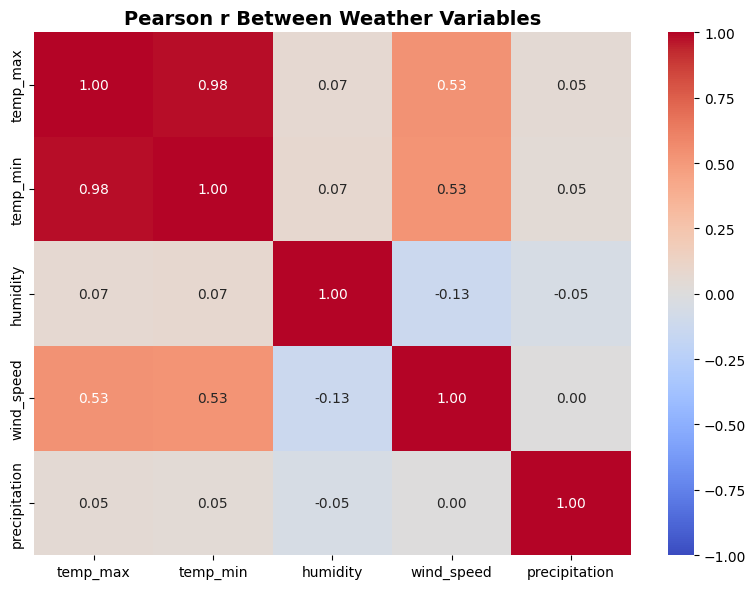

Notice the diagonal is all 1.0 (each variable correlates perfectly with itself)
Notice the table is symmetric (r from A to B = r from B to A)


In [11]:
# Create a pretty heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlationMatrix,
            annot=True,                      # show the r values as numbers
            cmap='coolwarm',                 # red = positive, blue = negative
            center=0,                        # center the color scale at 0
            fmt='.2f',                       # format to 2 decimal places
            vmin=-1, vmax=1)                 # scale from -1 to +1
plt.title('Pearson r Between Weather Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice the diagonal is all 1.0 (each variable correlates perfectly with itself)")
print("Notice the table is symmetric (r from A to B = r from B to A)")

### Step 5: Scatter Plot — The Strongest Relationship

Let's make a scatter plot of the two variables with the highest correlation.

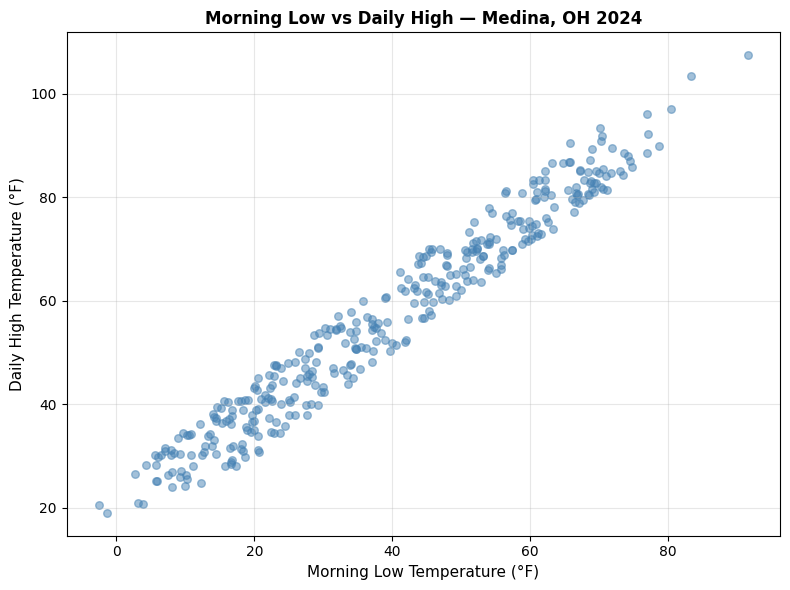

Pearson r: 0.978
R-squared: 0.956  (95.6% of variation explained)


In [12]:
# Make a scatter plot: morning low (x) vs daily high (y)
plt.figure(figsize=(8, 6))
plt.scatter(weatherData['temp_min'],          # x-axis = morning low
            weatherData['temp_max'],          # y-axis = daily high
            alpha=0.5,                        # 50% transparent (so overlaps are visible)
            color='steelblue',
            s=30)                             # size of dots

plt.xlabel('Morning Low Temperature (°F)', fontsize=11)
plt.ylabel('Daily High Temperature (°F)', fontsize=11)
plt.title('Morning Low vs Daily High — Medina, OH 2024', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation and R² for this pair
rValue = weatherData['temp_min'].corr(weatherData['temp_max'])
r2Value = rValue ** 2  # R² = r squared

print(f"Pearson r: {rValue:.3f}")
print(f"R-squared: {r2Value:.3f}  ({r2Value*100:.1f}% of variation explained)")

### Step 6: The "Cheating" Conversation

Look at that scatter plot. It's almost a **perfect straight line**.

BUT — think about what we're actually doing:
- **Input (X):** Morning low temperature (temp_min)
- **Output (Y):** Daily high temperature (temp_max)

These are measurements from the **same day**. Of course they're nearly identical! If it's 25°F at dawn, the high will probably be 35-40°F. If it's 65°F at dawn, the high will be 80°F.

**This isn't really machine learning. It's just basic thermodynamics: warmer mornings lead to warmer afternoons.**

We're using this example anyway to:
1. Learn the process (load, clean, explore, build, test, interpret)
2. See what a "too-easy" prediction looks like (R² = 0.92)
3. Then compare to the cars example, which is much more realistic

## Sub-Lesson 07b — Building Regression Models in Python

### Step 7: Build the Linear Regression Model

Now for the ML part. We'll train a model to predict `temp_max` using three features:
- `temp_min` (morning low)
- `humidity` (average % humidity)
- `wind_speed` (maximum mph)

We'll use **train/test split**: 80% of data to train, 20% to test (data the model has never seen).

In [13]:
# Define the features (X) and target (y)
# X = the inputs (what we use to predict)
# y = the output (what we're predicting)
featureColumns = ['temp_min', 'humidity', 'wind_speed']
X = weatherData[featureColumns]               # 3 input columns
y = weatherData['temp_max']                   # the target column

print(f"Features shape: {X.shape}  (rows, columns)")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:")
for col in featureColumns:
    print(f"  - {col}")

Features shape: (366, 3)  (rows, columns)
Target shape: (366,)

Feature columns:
  - temp_min
  - humidity
  - wind_speed


In [14]:
# Split the data: 80% for training, 20% for testing
# random_state=42 ensures we get the same split every time (reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} days")
print(f"Test set: {len(X_test)} days (the model will never see these)")
print(f"\nTotal: {len(X_train) + len(X_test)} days")

Training set: 292 days
Test set: 74 days (the model will never see these)

Total: 366 days


In [15]:
# Create an empty Linear Regression model
model = LinearRegression()

# .fit() trains the model — it finds the best coefficients
# The algorithm: minimize the sum of squared residuals
model.fit(X_train, y_train)

print("✓ Model trained successfully!")
print(f"  Coefficients found: {len(model.coef_)}")
print(f"  Intercept found: 1")

✓ Model trained successfully!
  Coefficients found: 3
  Intercept found: 1


### Step 8: Evaluate the Model

**R²** = what percentage of the temperature variation does our model explain?
**MAE** = on average, how many degrees off are our predictions?

In [16]:
# Use the trained model to make predictions on the test set
predictions = model.predict(X_test)          # [0] = array of predictions

# Calculate accuracy metrics
r2 = r2_score(y_test, predictions)           # R² = % of variation explained
mae = mean_absolute_error(y_test, predictions)  # MAE = average error in degrees

print("MODEL PERFORMANCE ON TEST DATA:")
print(f"  R² Score:  {r2:.4f}  ({r2*100:.1f}%)")
print(f"  MAE:       {mae:.2f} degrees F")
print(f"\nInterpretation:")
print(f"  Our model explains {r2*100:.1f}% of the variation in daily highs.")
print(f"  On average, our predictions are {mae:.1f} degrees off.")
print(f"\nReminder: This R² is high because temp_min and temp_max are nearly")
print(f"the same measurement. The cars model will be more realistic.")

MODEL PERFORMANCE ON TEST DATA:
  R² Score:  0.9483  (94.8%)
  MAE:       3.83 degrees F

Interpretation:
  Our model explains 94.8% of the variation in daily highs.
  On average, our predictions are 3.8 degrees off.

Reminder: This R² is high because temp_min and temp_max are nearly
the same measurement. The cars model will be more realistic.


### Step 9: Visualize Predictions vs Actual

Each point represents one test day. If our predictions were perfect, every point would land exactly on the red dashed line.

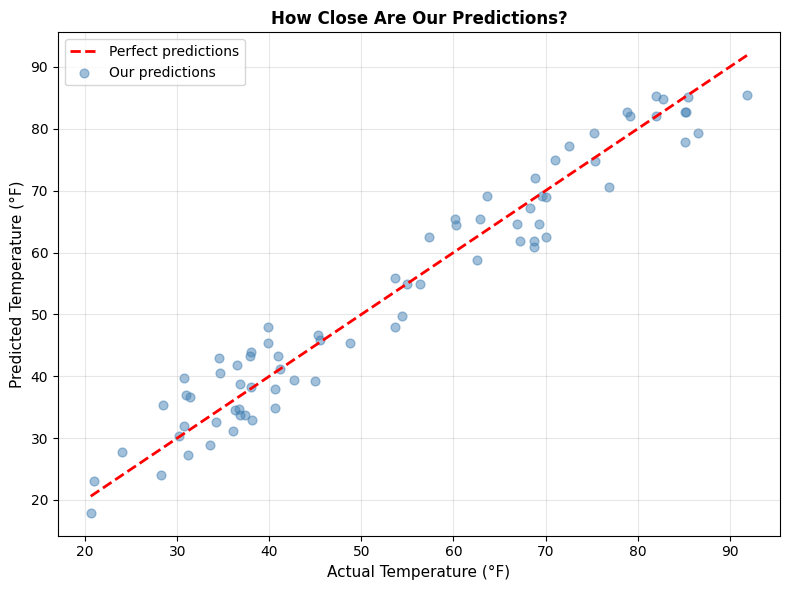

Dots close to the red line = good predictions
Dots far from the line = the model was off for that day


In [17]:
# Create a scatter plot showing actual vs predicted temperatures
plt.figure(figsize=(8, 6))

# Draw the "perfect prediction" diagonal line
minTemp = y_test.min()
maxTemp = y_test.max()
plt.plot([minTemp, maxTemp],                  # x range (actual temps)
         [minTemp, maxTemp],                  # y range (perfect predictions)
         'r--', linewidth=2, label='Perfect predictions')

# Plot our actual predictions
plt.scatter(y_test, predictions,              # x = actual, y = predicted
            alpha=0.5, color='steelblue', s=40,
            label='Our predictions')

plt.xlabel('Actual Temperature (°F)', fontsize=11)
plt.ylabel('Predicted Temperature (°F)', fontsize=11)
plt.title('How Close Are Our Predictions?', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Dots close to the red line = good predictions")
print("Dots far from the line = the model was off for that day")

### Step 10: Understand the Coefficients

The model learned a **formula**:

```
Predicted temp_max = (coef[0] × temp_min) + (coef[1] × humidity) + (coef[2] × wind_speed) + intercept
```

Each **coefficient** tells us how much that feature pushes the prediction up or down.

In [18]:
# Create a table of coefficients
coefficientTable = pd.DataFrame({
    'Feature': featureColumns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)  # sort by magnitude

print("WHAT THE MODEL LEARNED:\n")
print("The formula:")
print(f"  Predicted temp_max = ({model.coef_[0]:+.3f} × temp_min)")
print(f"                     + ({model.coef_[1]:+.3f} × humidity)")
print(f"                     + ({model.coef_[2]:+.3f} × wind_speed)")
print(f"                     + {model.intercept_:.2f}  (intercept)")

print("\nInterpretation:")
print(f"  Temp_min:    {model.coef_[0]:+.3f}  → Each 1° warmer morning ≈ {model.coef_[0]:.2f}° warmer high")
print(f"  Humidity:    {model.coef_[1]:+.3f}  → Each 1% more humidity ≈ {model.coef_[1]:.3f}° cooler high")
print(f"  Wind speed:  {model.coef_[2]:+.3f}  → Each 1 mph more wind ≈ {model.coef_[2]:.3f}° cooler high")

WHAT THE MODEL LEARNED:

The formula:
  Predicted temp_max = (+0.922 × temp_min)
                     + (-0.006 × humidity)
                     + (+0.086 × wind_speed)
                     + 19.95  (intercept)

Interpretation:
  Temp_min:    +0.922  → Each 1° warmer morning ≈ 0.92° warmer high
  Humidity:    -0.006  → Each 1% more humidity ≈ -0.006° cooler high
  Wind speed:  +0.086  → Each 1 mph more wind ≈ 0.086° cooler high


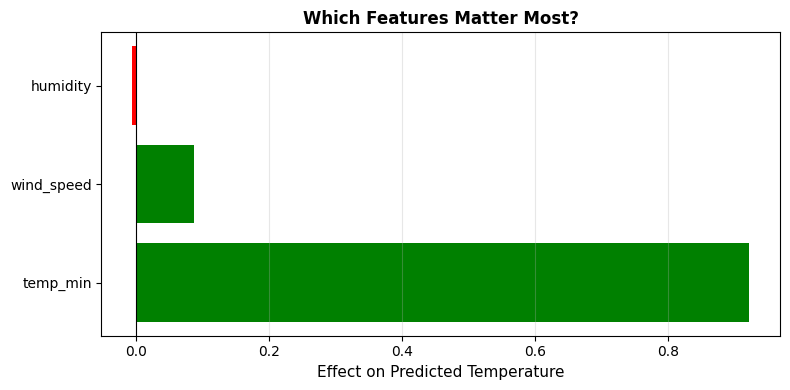

Green bars = positive effect (pushes temperature UP)
Red bars = negative effect (pushes temperature DOWN)


In [19]:
# Bar chart showing which features have the biggest impact
plt.figure(figsize=(8, 4))

# Color: green for positive, red for negative
colors = ['green' if c > 0 else 'red' for c in coefficientTable['Coefficient']]

plt.barh(coefficientTable['Feature'],         # y-axis = feature names
         coefficientTable['Coefficient'],     # x-axis = coefficient values
         color=colors)
plt.xlabel('Effect on Predicted Temperature', fontsize=11)
plt.title('Which Features Matter Most?', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)  # vertical line at 0
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Green bars = positive effect (pushes temperature UP)")
print("Red bars = negative effect (pushes temperature DOWN)")

### Step 11: Make a Prediction

Let's use the trained model to predict the high temperature for a hypothetical day. Try changing the values!

In [20]:
# Create a hypothetical day's conditions
# Column names MUST match what the model was trained on
hypotheticalDay = pd.DataFrame({
    'temp_min': [45],                        # morning low = 45 F
    'humidity': [65],                        # humidity = 65%
    'wind_speed': [10]                       # wind speed = 10 mph
})

# Make the prediction
predictedTemp = model.predict(hypotheticalDay)[0]  # [0] grabs the single number

print(f"Given conditions:")
print(f"  Morning low = 45°F")
print(f"  Humidity = 65%")
print(f"  Wind speed = 10 mph")
print(f"\nModel's prediction: {predictedTemp:.1f}°F")

print(f"\nLet's verify the math manually:")
manualCalc = (model.coef_[0] * 45 +
              model.coef_[1] * 65 +
              model.coef_[2] * 10 +
              model.intercept_)
print(f"  ({model.coef_[0]:.3f} × 45) + ({model.coef_[1]:.3f} × 65) + ({model.coef_[2]:.3f} × 10) + {model.intercept_:.2f}")
print(f"  = {manualCalc:.1f}°F  ✓ (same answer!)")

Given conditions:
  Morning low = 45°F
  Humidity = 65%
  Wind speed = 10 mph

Model's prediction: 61.9°F

Let's verify the math manually:
  (0.922 × 45) + (-0.006 × 65) + (0.086 × 10) + 19.95
  = 61.9°F  ✓ (same answer!)


## Try This: Make Your Own Prediction

In the cell below, change the hypothetical day's values and see how the prediction changes. What day conditions would give the highest prediction?

In [21]:
# YOUR TURN: Change these values and re-run the cell
myDay = pd.DataFrame({
    'temp_min': [50],                        # Change this
    'humidity': [50],                        # Change this
    'wind_speed': [5]                        # Change this
})

myPrediction = model.predict(myDay)[0]

print(f"Your conditions:")
print(f"  Morning low = {myDay['temp_min'].iloc[0]}°F")
print(f"  Humidity = {myDay['humidity'].iloc[0]}%")
print(f"  Wind speed = {myDay['wind_speed'].iloc[0]} mph")
print(f"\nPredicted high: {myPrediction:.1f}°F")

Your conditions:
  Morning low = 50°F
  Humidity = 50%
  Wind speed = 5 mph

Predicted high: 66.2°F


---

## Summary: What We Learned

**Sub-Lesson 07a — Correlation & Pearson r:**
- Pearson r measures how strongly two variables are related (-1 to +1)
- R² = r × r tells us the percentage of variation explained
- Correlation heatmaps show at a glance which pairs are strongly related

**Sub-Lesson 07b — Building Regression Models:**
- Linear regression finds the "best fit" line through data
- Train/test split (80/20) ensures we evaluate honestly
- R² and MAE tell us how good the model is
- Coefficients show how each feature affects the prediction
- The weather example was "cheating" — temp_min and temp_max are nearly identical measurements

**Next:** The task notebooks will have you build more realistic models on the EPA cars data, where the relationship is weaker and more interesting.